# NumCompute Stream Demo

This notebook shows the NumCompute Stream package.

It actually shows:

 1.Loading a CSV dataset using custom `io.py`
 2.Splitting data into train/test sets
 3.Splitting data into chunks for streaming learning
 4.Training a single decision tree with `.partial_fit()`
 5.Training an ensemble model with `.partial_fit()`
 6.Logging accuracy over chunks
 7.Visualising metrics using `visualise.py`
 8.Showing final predictions and test accuracy

In [1]:
import sys
from pathlib import Path

import numpy as np

current_dir = Path.cwd()

if current_dir.name == "demo":
    project_root = current_dir.parent
    demo_dir = current_dir
else:
    project_root = current_dir
    demo_dir = project_root / "demo"

sys.path.append(str(project_root))

from numcompute_stream.io import load_csv, train_test_split, make_chunks
from numcompute_stream.preprocessing import SimpleImputer, StandardScaler
from numcompute_stream.tree import DecisionTreeClassifier
from numcompute_stream.ensemble import EnsembleClassifier
from numcompute_stream.pipeline import Pipeline
from numcompute_stream.metrics import Accuracy
from numcompute_stream.stream import StreamTrainer
from numcompute_stream.visualise import (
    plot_metric_over_time,
    compare_models,
    plot_predictions_vs_ground_truth,
    plot_error_over_time,
)

print("Imports successful")
print("Project root:", project_root)
print("Demo folder:", demo_dir)

Imports successful
Project root: f:\Adelaide University Ethics Assignment\Prog for AI Assignment 2\Assignment 2
Demo folder: f:\Adelaide University Ethics Assignment\Prog for AI Assignment 2\Assignment 2\demo


In [2]:
dataset_path = demo_dir / "sample_data.csv"

X, y = load_csv(
    file_path=str(dataset_path),
    target_column=-1,
    has_header=True,
)

print("Dataset was loaded successfully using custom io.py")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst five rows of X=")
print(X[:5])

print("\nFirst five labels=")
print(y[:5])

Dataset was loaded successfully using custom io.py
X shape: (30, 4)
y shape: (30,)

First five rows of X=
[[ 2.1 52.  42.   3. ]
 [ 3.2 60.  50.   4. ]
 [ 1.9 48.  40.   3. ]
 [ 4.  62.  55.   5. ]
 [ 2.5 58.  46.   4. ]]

First five labels=
[0. 0. 0. 0. 0.]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    shuffle=True,
    random_state=42,
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (22, 4)
Testing data shape: (8, 4)


In [4]:
chunk_size = 6

train_chunks = list(make_chunks(
    X_train,
    y_train,
    chunk_size=chunk_size,
))

print("Number of streaming chunks=", len(train_chunks))

for i, (X_chunk, y_chunk) in enumerate(train_chunks, start=1):
    print(f"Chunk {i}: X={X_chunk.shape}, y={y_chunk.shape}")

Number of streaming chunks= 4
Chunk 1: X=(6, 4), y=(6,)
Chunk 2: X=(6, 4), y=(6,)
Chunk 3: X=(6, 4), y=(6,)
Chunk 4: X=(4, 4), y=(4,)


In [5]:
tree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(
        max_depth=4,
        min_samples_split=2,
        criterion="gini",
        random_state=42,
    )),
])

print("Single decision tree pipeline was created")

Single decision tree pipeline was created


In [6]:
ensemble_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", EnsembleClassifier(
        n_estimators=5,
        max_depth=4,
        min_samples_split=2,
        criterion="gini",
        max_features="sqrt",
        bootstrap=True,
        random_state=42,
    )),
])

print("Ensemble pipeline was created")

Ensemble pipeline was created


In [7]:
tree_trainer = StreamTrainer(
    pipeline=tree_pipeline,
    metrics={"accuracy": Accuracy()},
    name="Single Decision Tree",
)

ensemble_trainer = StreamTrainer(
    pipeline=ensemble_pipeline,
    metrics={"accuracy": Accuracy()},
    name="Bagging Ensemble",
)

print("Stream trainers were created")

Stream trainers were created


In [8]:
for chunk_number, (X_chunk, y_chunk) in enumerate(train_chunks, start=1):
    print(f"\nProcessing chunk {chunk_number}")

    tree_log = tree_trainer.fit_score_chunk(X_chunk, y_chunk)
    ensemble_log = ensemble_trainer.fit_score_chunk(X_chunk, y_chunk)

    print("Tree log:", tree_log)
    print("Ensemble log:", ensemble_log)


Processing chunk 1
Tree log: {'model': 'Single Decision Tree', 'chunk': 1, 'samples_in_chunk': 6, 'samples_seen': 6, 'train_time_seconds': 0.004719299991847947, 'memory_bytes': 480, 'accuracy': 1.0}
Ensemble log: {'model': 'Bagging Ensemble', 'chunk': 1, 'samples_in_chunk': 6, 'samples_seen': 6, 'train_time_seconds': 0.006351800009724684, 'memory_bytes': 480, 'accuracy': 1.0}

Processing chunk 2
Tree log: {'model': 'Single Decision Tree', 'chunk': 2, 'samples_in_chunk': 6, 'samples_seen': 12, 'train_time_seconds': 0.006007999996654689, 'memory_bytes': 480, 'accuracy': 1.0}
Ensemble log: {'model': 'Bagging Ensemble', 'chunk': 2, 'samples_in_chunk': 6, 'samples_seen': 12, 'train_time_seconds': 0.009937900002114475, 'memory_bytes': 480, 'accuracy': 1.0}

Processing chunk 3
Tree log: {'model': 'Single Decision Tree', 'chunk': 3, 'samples_in_chunk': 6, 'samples_seen': 18, 'train_time_seconds': 0.0060206999914953485, 'memory_bytes': 480, 'accuracy': 1.0}
Ensemble log: {'model': 'Bagging Ens

In [9]:
print("Tree summary:")
print(tree_trainer.summary())

print("\nEnsemble summary:")
print(ensemble_trainer.summary())

Tree summary:
{'model': 'Single Decision Tree', 'chunks_processed': 4, 'samples_seen': 22, 'latest_metrics': {'accuracy': 1.0}}

Ensemble summary:
{'model': 'Bagging Ensemble', 'chunks_processed': 4, 'samples_seen': 22, 'latest_metrics': {'accuracy': 1.0}}


In [10]:
tree_accuracy = tree_trainer.get_metric_history("accuracy")
ensemble_accuracy = ensemble_trainer.get_metric_history("accuracy")

print("Tree accuracy history:")
print(tree_accuracy)

print("\nEnsemble accuracy history:")
print(ensemble_accuracy)

Tree accuracy history:
[1.0, 1.0, 1.0, 1.0]

Ensemble accuracy history:
[1.0, 1.0, 1.0, 1.0]


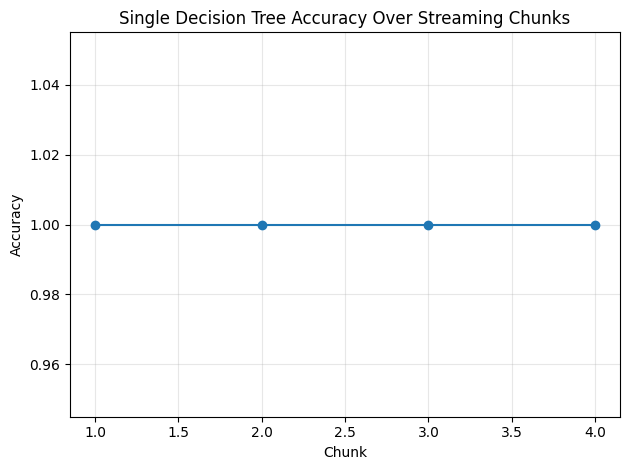

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Single Decision Tree Accuracy Over Streaming Chunks'}, xlabel='Chunk', ylabel='Accuracy'>)

In [11]:
plot_metric_over_time(
    tree_accuracy,
    title="Single Decision Tree Accuracy Over Streaming Chunks",
    ylabel="Accuracy",
)

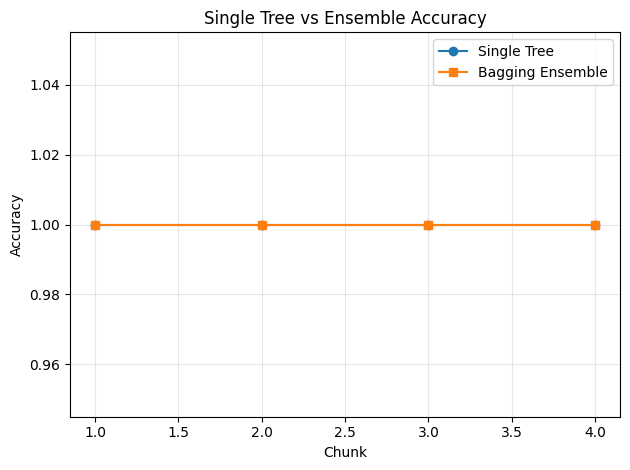

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Single Tree vs Ensemble Accuracy'}, xlabel='Chunk', ylabel='Accuracy'>)

In [12]:
compare_models(
    tree_accuracy,
    ensemble_accuracy,
    labels=("Single Tree", "Bagging Ensemble"),
    title="Single Tree vs Ensemble Accuracy",
    ylabel="Accuracy",
)

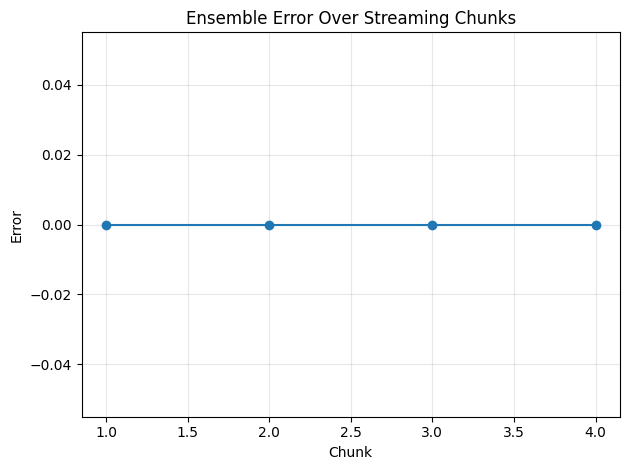

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Ensemble Error Over Streaming Chunks'}, xlabel='Chunk', ylabel='Error'>)

In [13]:
plot_error_over_time(
    ensemble_accuracy,
    title="Ensemble Error Over Streaming Chunks",
)

In [14]:
tree_predictions = tree_pipeline.predict(X_test)
ensemble_predictions = ensemble_pipeline.predict(X_test)

print("True labels:")
print(y_test)

print("\nTree predictions:")
print(tree_predictions)

print("\nEnsemble predictions:")
print(ensemble_predictions)

True labels:
[0. 1. 0. 1. 1. 0. 0. 0.]

Tree predictions:
[0. 1. 0. 1. 1. 0. 0. 0.]

Ensemble predictions:
[0. 1. 0. 1. 1. 0. 0. 0.]


In [15]:
tree_test_accuracy = np.mean(tree_predictions == y_test)
ensemble_test_accuracy = np.mean(ensemble_predictions == y_test)

print("The Final test accuracy")
print("Single decision tree is:", tree_test_accuracy)
print("Bagging ensemble is:", ensemble_test_accuracy)

The Final test accuracy
Single decision tree is: 1.0
Bagging ensemble is: 1.0


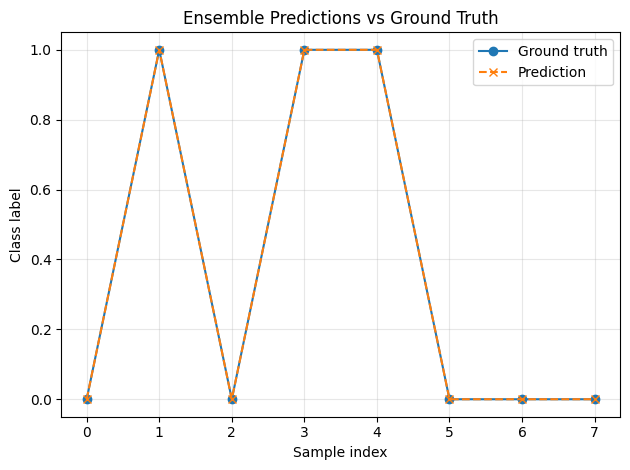

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Ensemble Predictions vs Ground Truth'}, xlabel='Sample index', ylabel='Class label'>)

In [16]:
plot_predictions_vs_ground_truth(
    y_test,
    ensemble_predictions,
    title="Ensemble Predictions vs Ground Truth",
)

## Conclusion

This demo successfully shows that the NumCompute Stream package can load CSV data using a custom I/O module. It splits data into chunks, train models incrementally using `.partial_fit()`, log streaming accuracy, compare a single decision tree with an ensemble model.It can also visualise results over time using matplotlib.

It satisfies the assignment requirements for streaming learning, model ensembling, pipeline usage, metrics and built-in visualisation.